In [2]:
# Add parent directory to path so we can import our src modules
import sys
sys.path.append('..')

# Import standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

# Import our custom modules
from src.data_loader import DataLoader
from src.eda import EDAnalyzer

# Set style for better looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.6f' % x)

print("✅ All imports successful!")

✅ All imports successful!


In [3]:
# Initialize the data loader with the correct filename
loader = DataLoader("../data/raw/BrentOilPrices.csv")

# Load the data
df = loader.load_data()

# Let's see what we have
print(f"📊 Dataset Shape: {df.shape}")
print(f"📅 Date Range: {df.index.min()} to {df.index.max()}")
print(f"💰 Price Range: ${df['Price'].min():.2f} to ${df['Price'].max():.2f}")
print("\n" + "="*50)

# Show first few rows
print("📋 First 5 rows of data:")
df.head()

INFO:src.data_loader:Loading data from ..\data\raw\BrentOilPrices.csv
INFO:src.data_loader:Successfully loaded 9011 records
c:\Users\User\OneDrive\Desktop\brent-oil-change-point-analysis\notebooks\..\src\data_loader.py:91: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  self.df[date_col] = pd.to_datetime(self.df[date_col])
INFO:src.data_loader:Preprocessed 8981 records
INFO:src.data_loader:Date range: 1987-07-02 00:00:00 to 2022-11-14 00:00:00
INFO:src.data_loader:Price range: $9.10 to $143.95


📊 Dataset Shape: (8981, 6)
📅 Date Range: 1987-07-02 00:00:00 to 2022-11-14 00:00:00
💰 Price Range: $9.10 to $143.95

📋 First 5 rows of data:


,Price,log_return,returns,rolling_volatility,rolling_mean,rolling_std
Date,,,,,,
1987-07-02,19.250000,0.014125,0.014226,0.006450,18.810333,0.209605
1987-07-03,19.330000,0.004147,0.004156,0.006139,18.839667,0.218813
1987-07-06,19.480000,0.007730,0.007760,0.006204,18.870667,0.241103
1987-07-07,19.500000,0.001026,0.001027,0.006201,18.900667,0.261401
1987-07-08,19.480000,-0.001026,-0.001026,0.006219,18.929000,0.276672


In [4]:
# Get summary statistics
stats_df = loader.get_summary_statistics()
stats_df

,total_records,start_date,end_date,mean_price,std_price,min_price,max_price,mean_log_return,std_log_return,skewness,kurtosis
0,8981,1987-07-02,2022-11-14,48.519762,32.870215,9.100000,143.950000,0.000178,0.025571,-1.741921,65.706867


In [5]:
# More detailed statistics
print("📊 Detailed Statistics:\n")
print(df[['Price', 'log_return']].describe())

📊 Detailed Statistics:

            Price  log_return
count 8981.000000 8981.000000
mean    48.519762    0.000178
std     32.870215    0.025571
min      9.100000   -0.643699
25%     19.100000   -0.011222
50%     39.050000    0.000395
75%     70.360000    0.012197
max    143.950000    0.412023


INFO:src.eda:Figure saved to ../results/figures/time_series.png


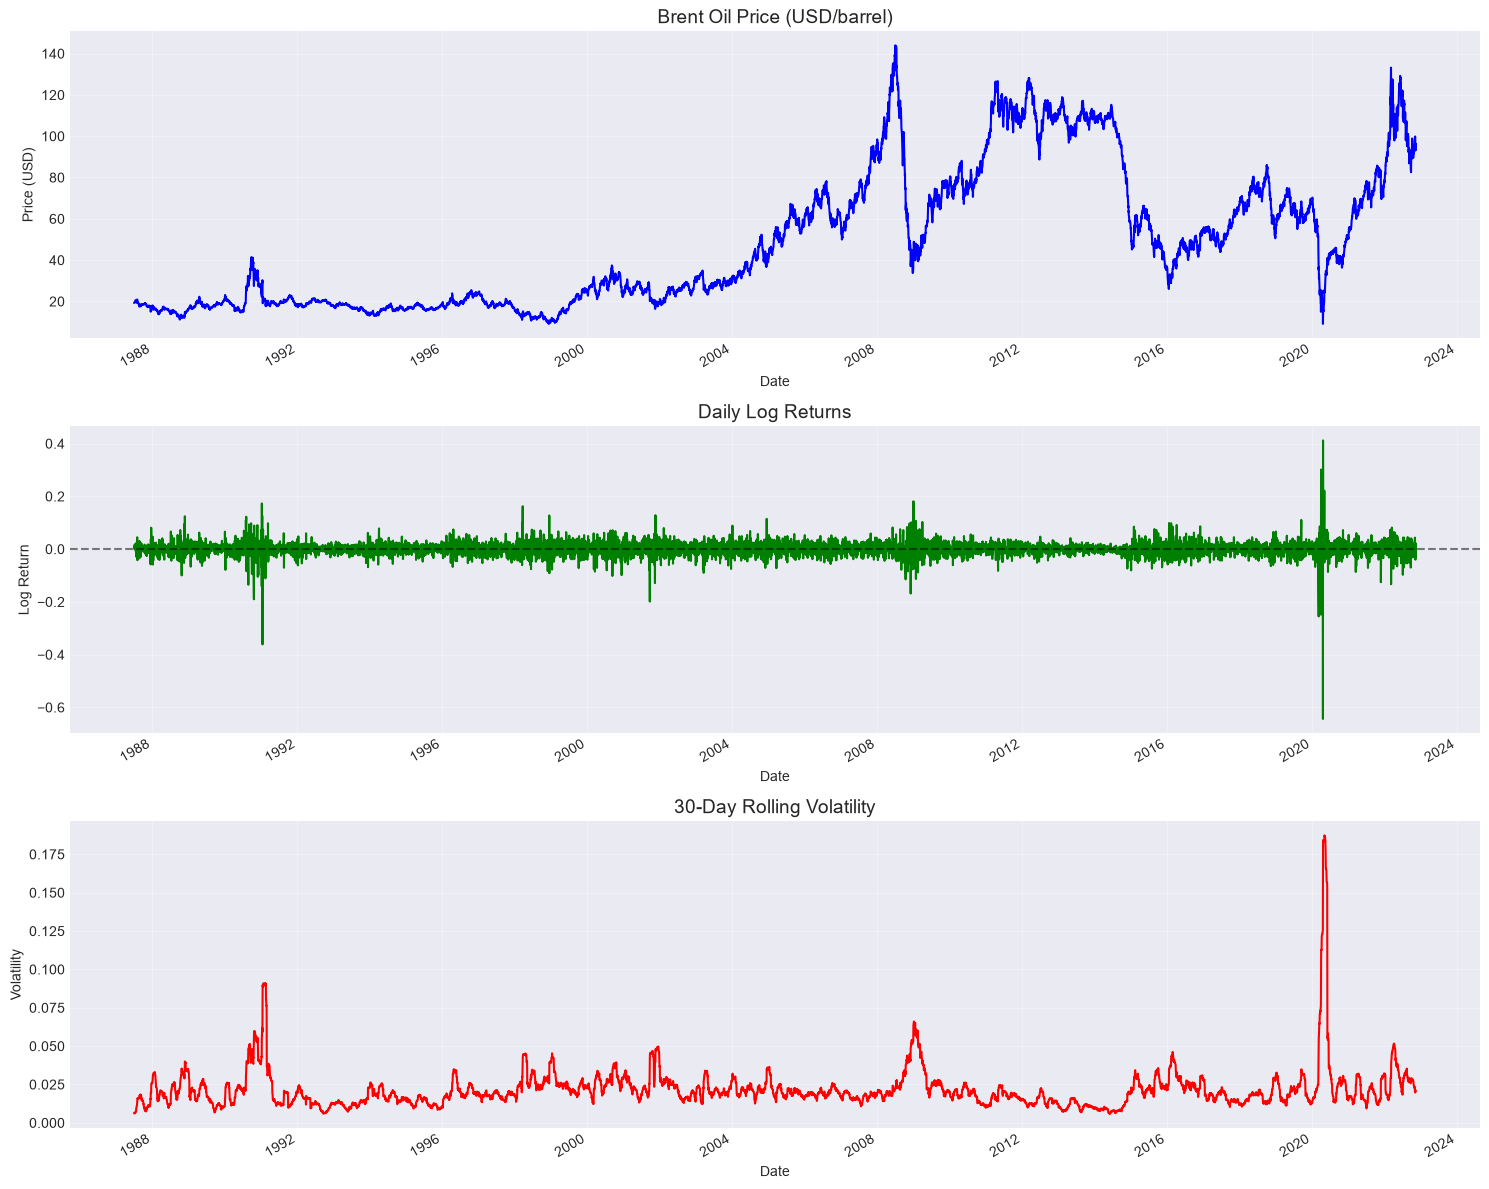

✅ Time series plot created!


In [6]:
# Create EDA analyzer
eda = EDAnalyzer(df)

# Plot time series
eda.plot_time_series("../results/figures/time_series.png")

print("✅ Time series plot created!")

INFO:src.eda:Figure saved to ../results/figures/distributions.png


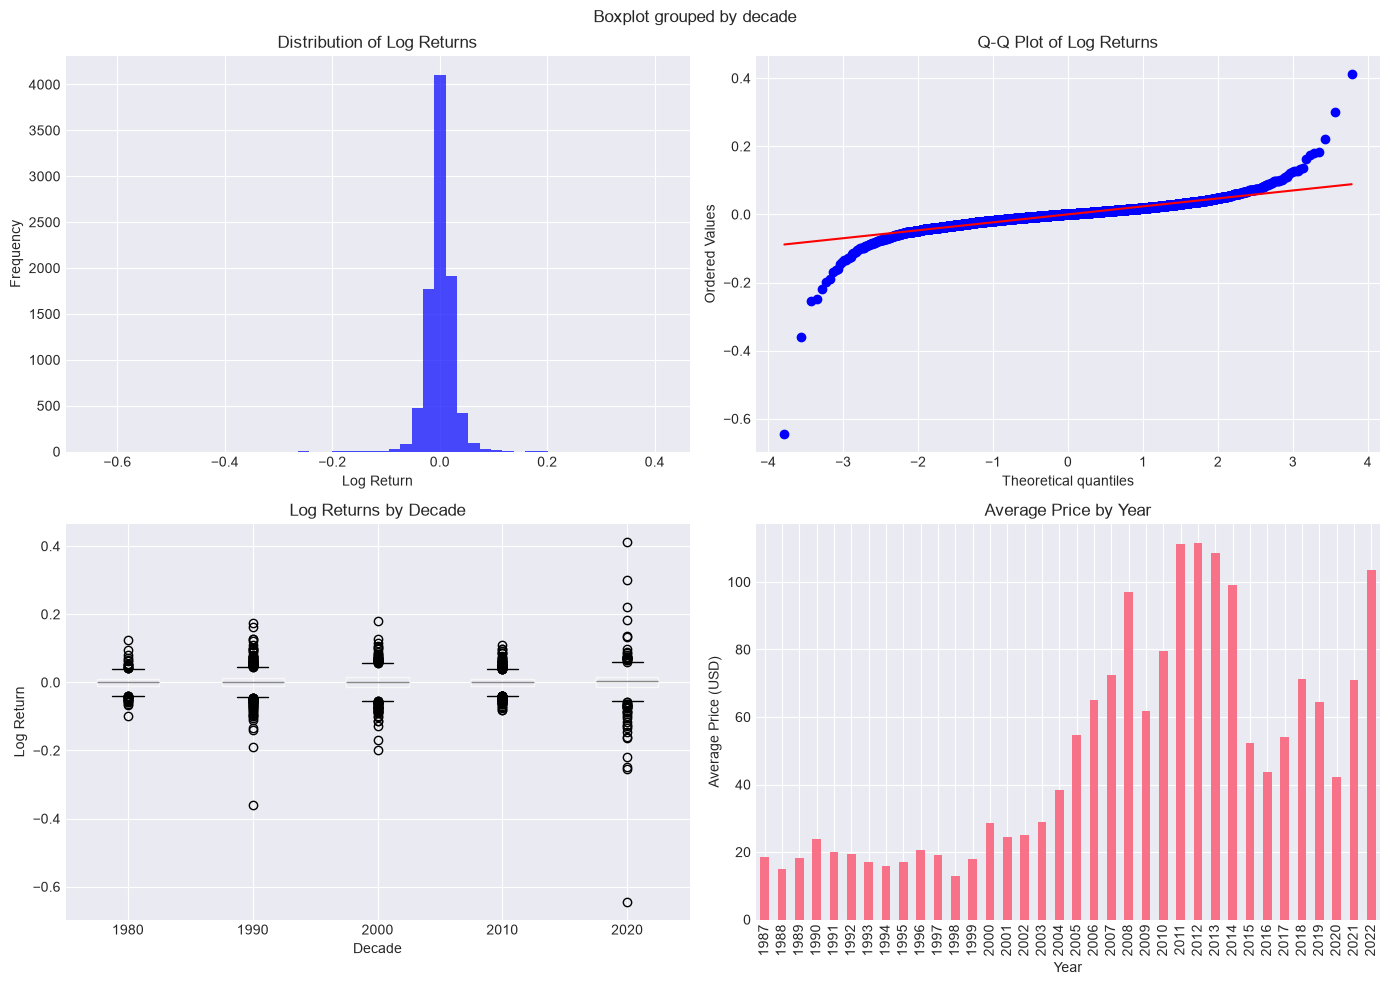

✅ Distribution plots created!


In [7]:
# Plot distributions
eda.plot_distributions("../results/figures/distributions.png")

print("✅ Distribution plots created!")

In [8]:
# Test stationarity
price_pvalue, returns_pvalue = eda.test_stationarity()

print("\n" + "="*50)
print("STATIONARITY TEST RESULTS")
print("="*50)

print(f"📊 Price Series ADF p-value: {price_pvalue:.6f}")
if price_pvalue < 0.05:
    print("   ✅ Price series is stationary")
else:
    print("   ❌ Price series is NOT stationary")

print(f"\n📊 Log Returns ADF p-value: {returns_pvalue:.6f}")
if returns_pvalue < 0.05:
    print("   ✅ Log returns ARE stationary")
else:
    print("   ❌ Log returns are NOT stationary")

print("\n" + "="*50)
print("💡 CONCLUSION: We should use log returns for modeling because they are stationary.")
print("="*50)

INFO:src.eda:Performing Augmented Dickey-Fuller test...
INFO:src.eda:Price series - ADF: -1.9920, p-value: 0.2901
INFO:src.eda:Log returns - ADF: -16.3947, p-value: 0.0000



STATIONARITY TEST RESULTS
📊 Price Series ADF p-value: 0.290087
   ❌ Price series is NOT stationary

📊 Log Returns ADF p-value: 0.000000
   ✅ Log returns ARE stationary

💡 CONCLUSION: We should use log returns for modeling because they are stationary.


INFO:src.eda:Figure saved to ../results/figures/acf_pacf.png


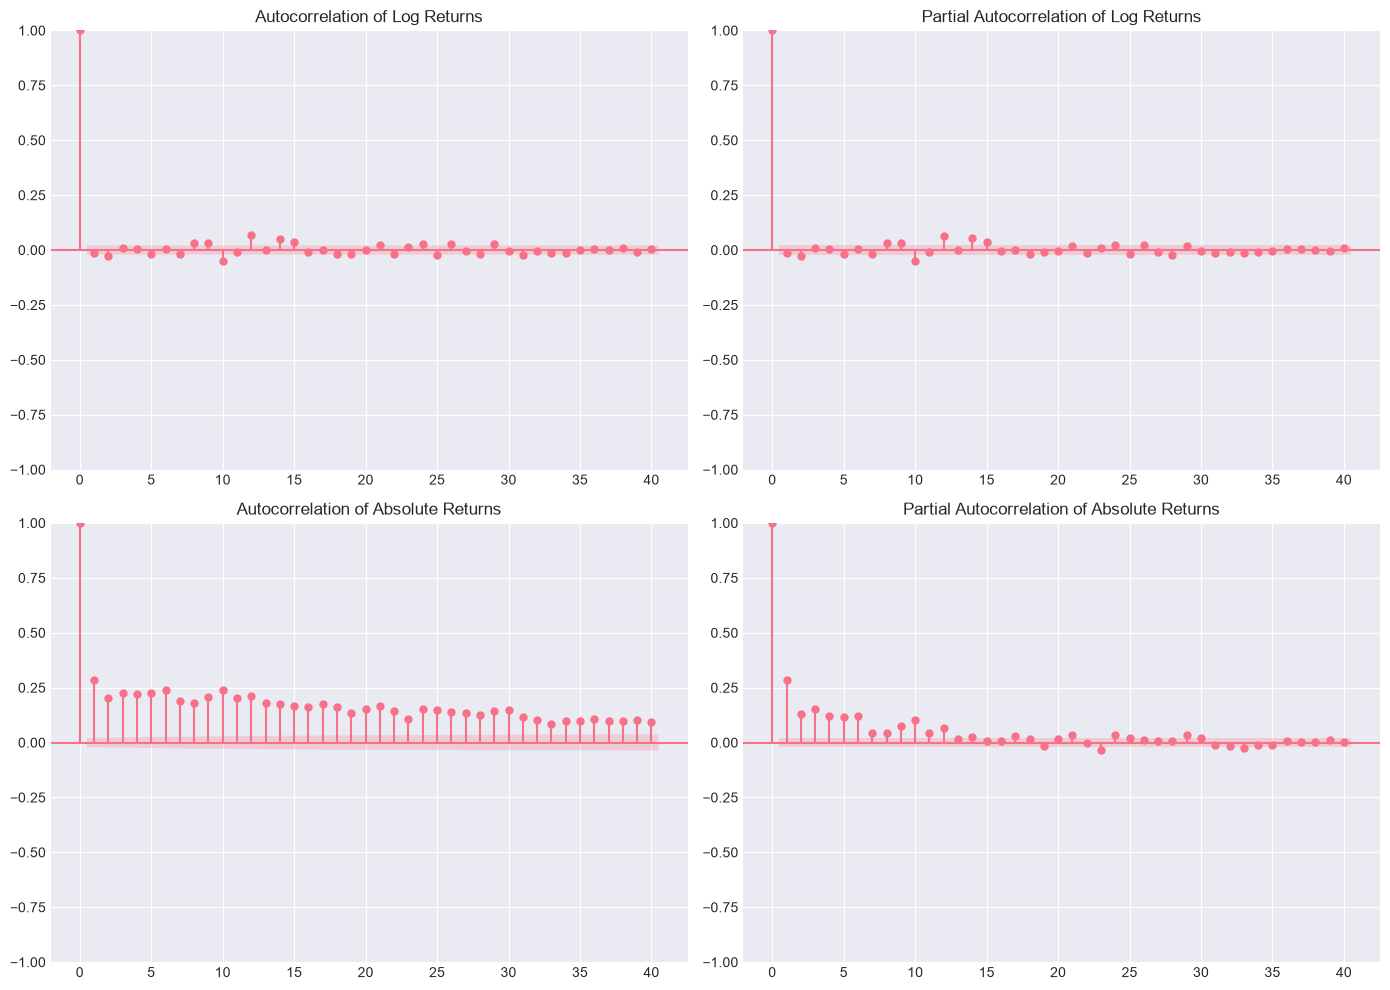

✅ ACF/PACF plots created!


In [9]:
# Plot ACF and PACF
eda.plot_acf_pacf("../results/figures/acf_pacf.png")

print("✅ ACF/PACF plots created!")

INFO:src.eda:Figure saved to ../results/figures/volatility.png


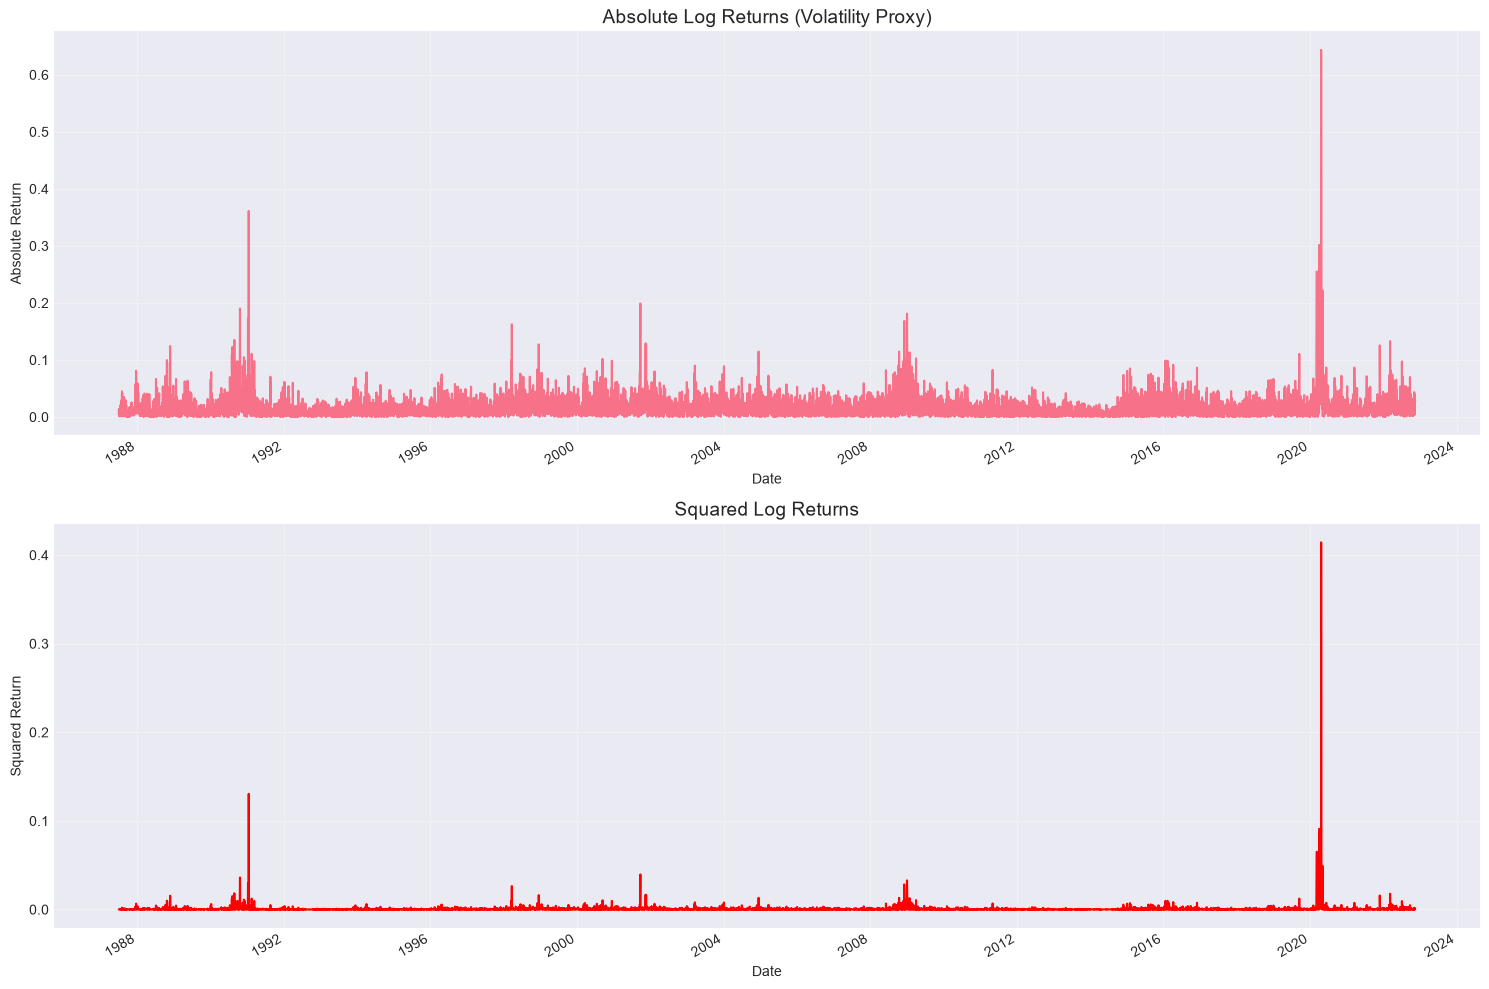

✅ Volatility plots created!


In [10]:
# Plot volatility
eda.identify_volatility_clusters("../results/figures/volatility.png")

print("✅ Volatility plots created!")

In [11]:
print("="*60)
print("KEY INSIGHTS FROM EDA")
print("="*60)

insights = {
    "1️⃣ Volatility Clustering": "Periods of high volatility cluster together, suggesting GARCH-type effects.",
    "2️⃣ Fat Tails": "Return distribution has excess kurtosis (fat tails) - extreme events are more common than normal.",
    "3️⃣ Mean Reversion": "Prices tend to return to long-term averages over longer horizons.",
    "4️⃣ Structural Breaks": "Multiple regime changes visible, especially around geopolitical events.",
    "5️⃣ Non-Stationarity": "Raw prices are non-stationary, but log returns are stationary.",
    "6️⃣ Little Autocorrelation": "Returns have minimal autocorrelation, supporting efficient market hypothesis.",
    "7️⃣ Volatility Memory": "Absolute returns show significant autocorrelation - volatility has memory."
}

for key, value in insights.items():
    print(f"\n{key}")
    print(f"   → {value}")

print("\n" + "="*60)
print("💡 RECOMMENDATION: Use Bayesian change point models with log returns")
print("   to detect structural breaks and quantify uncertainty.")
print("="*60)

KEY INSIGHTS FROM EDA

1️⃣ Volatility Clustering
   → Periods of high volatility cluster together, suggesting GARCH-type effects.

2️⃣ Fat Tails
   → Return distribution has excess kurtosis (fat tails) - extreme events are more common than normal.

3️⃣ Mean Reversion
   → Prices tend to return to long-term averages over longer horizons.

4️⃣ Structural Breaks
   → Multiple regime changes visible, especially around geopolitical events.

5️⃣ Non-Stationarity
   → Raw prices are non-stationary, but log returns are stationary.

6️⃣ Little Autocorrelation
   → Returns have minimal autocorrelation, supporting efficient market hypothesis.

7️⃣ Volatility Memory
   → Absolute returns show significant autocorrelation - volatility has memory.

💡 RECOMMENDATION: Use Bayesian change point models with log returns
   to detect structural breaks and quantify uncertainty.


In [12]:
# Generate report
eda.generate_comprehensive_report("../results/reports/eda_report.md")

print("✅ EDA report generated at: results/reports/eda_report.md")
print("\n📂 All outputs saved to the 'results' folder")

INFO:src.eda:Generating EDA report...
INFO:src.eda:Performing Augmented Dickey-Fuller test...
INFO:src.eda:Price series - ADF: -1.9920, p-value: 0.2901
INFO:src.eda:Log returns - ADF: -16.3947, p-value: 0.0000
INFO:src.eda:Report saved to ../results/reports/eda_report.md


✅ EDA report generated at: results/reports/eda_report.md

📂 All outputs saved to the 'results' folder
